# Task 3: Linear Regression - House Price Prediction

This notebook implements and evaluates Simple and Multiple Linear Regression models to predict house prices. It covers data preprocessing, model training, evaluation metrics, residual analysis, and advanced regularization techniques.

All steps are structured to ensure reproducibility and follow machine learning best practices.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

### Cell 1: Import all required libraries and load the dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Set plot style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('Housing.csv')

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Cell 2: Preprocess categorical features and separate the target variable.
Machine learning models require numerical input. We will:
1. Convert binary categorical columns (`yes`/`no`) to `1`/`0`.
2. Apply One-Hot Encoding to the `furnishingstatus` column (dropping the first category to avoid the dummy variable trap).
3. Separate the features (`X`) from the target variable (`y` = `price`).

In [11]:
# 1. Convert 'yes'/'no' columns to 1/0
yes_no_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# 2. One-Hot Encode 'furnishingstatus' 
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# 3. Define Features (X) and Target (y)
X = df.drop('price', axis=1)
y = df['price']

print("Preprocessed Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

Preprocessed Features (X) Shape: (545, 13)
Target (y) Shape: (545,)


### Cell 3: Split data into train and test sets.
We split the dataset so that 80% of the data is used to train the model, and 20% is held back to evaluate how well the model generalizes to unseen data. A `random_state` is set for reproducibility.

In [ ]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# --- Save split data as CSV files ---
# Optional: reset index to avoid confusion later
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=['price'])
y_test.to_csv('y_test.csv', index=False, header=['price'])

print("✅ Train-test split saved to CSV files.")

Training set size: 436 rows
Testing set size: 109 rows
✅ Train-test split saved to CSV files.


### Cell 4: Fit Simple and Multiple Linear Regression models.
We will train two baseline models:
1. **Simple Linear Regression**: Predicts `price` using only the `area` feature.
2. **Multiple Linear Regression**: Predicts `price` using all available features.

In [ ]:
# --- A. Simple Linear Regression (Price vs. Area) ---
X_train_simple = X_train[['area']]
X_test_simple = X_test[['area']]

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)

# --- B. Multiple Linear Regression (All Features) ---
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

print("✅ Both models fitted successfully!")

✅ Both models fitted successfully!


### Cell 5: Evaluate models using MAE, MSE, and R² metrics.
- **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual prices.
- **MSE (Mean Squared Error)**: Average squared difference (penalizes larger errors more).
- **R² (R-squared)**: Proportion of variance in the target explained by the model (closer to 1.0 is better).

In [ ]:
# --- Evaluate Simple Linear Regression ---
y_pred_simple = model_simple.predict(X_test_simple)
print("📊 --- Simple Linear Regression Evaluation ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_simple):,.2f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred_simple):,.2f}")
print(f"R²:   {r2_score(y_test, y_pred_simple):.4f}\n")

# --- Evaluate Multiple Linear Regression ---
y_pred_multiple = model_multiple.predict(X_test)
print("📊 --- Multiple Linear Regression Evaluation ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_multiple):,.2f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred_multiple):,.2f}")
print(f"R²:   {r2_score(y_test, y_pred_multiple):.4f}")

📊 --- Simple Linear Regression Evaluation ---
MAE:  1,474,748.13
MSE:  3,675,286,604,768.19
R²:   0.2729

📊 --- Multiple Linear Regression Evaluation ---
MAE:  970,043.40
MSE:  1,754,318,687,330.66
R²:   0.6529


### Cell 6: Plot the regression line and interpret feature coefficients.
Visualizing the simple regression line helps understand the direct relationship. For multiple regression, we extract and plot the coefficients to understand which features have the highest positive or negative impact on the price (holding all other features constant).

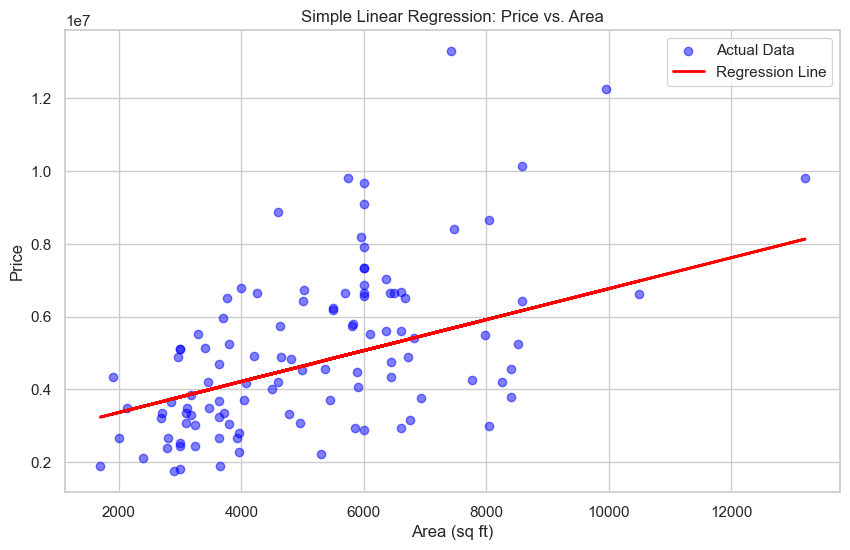

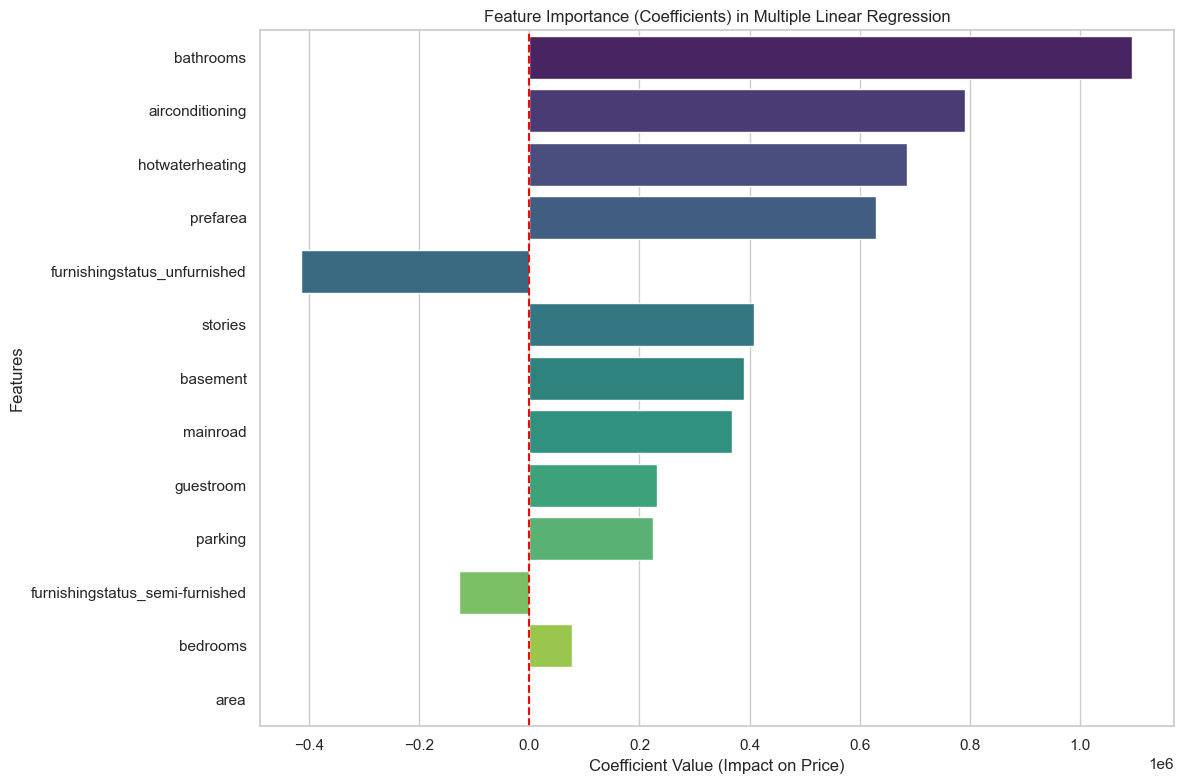

In [15]:
# --- A. Plot Simple Linear Regression Line ---
plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple, y_test, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Price vs. Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend()
plt.show()

# --- B. Interpret Multiple Linear Regression Coefficients ---
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_multiple.coef_})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Coefficients) in Multiple Linear Regression')
plt.xlabel('Coefficient Value (Impact on Price)')
plt.ylabel('Features')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5) # Reference line at 0
plt.tight_layout()
plt.show()

### Cell 7: Residual analysis to validate linear regression assumptions.
A good linear regression model should have residuals (errors) that are:
1. Randomly distributed around zero (no clear patterns, indicating homoscedasticity).
2. Approximately normally distributed (checked via a histogram with a KDE curve).

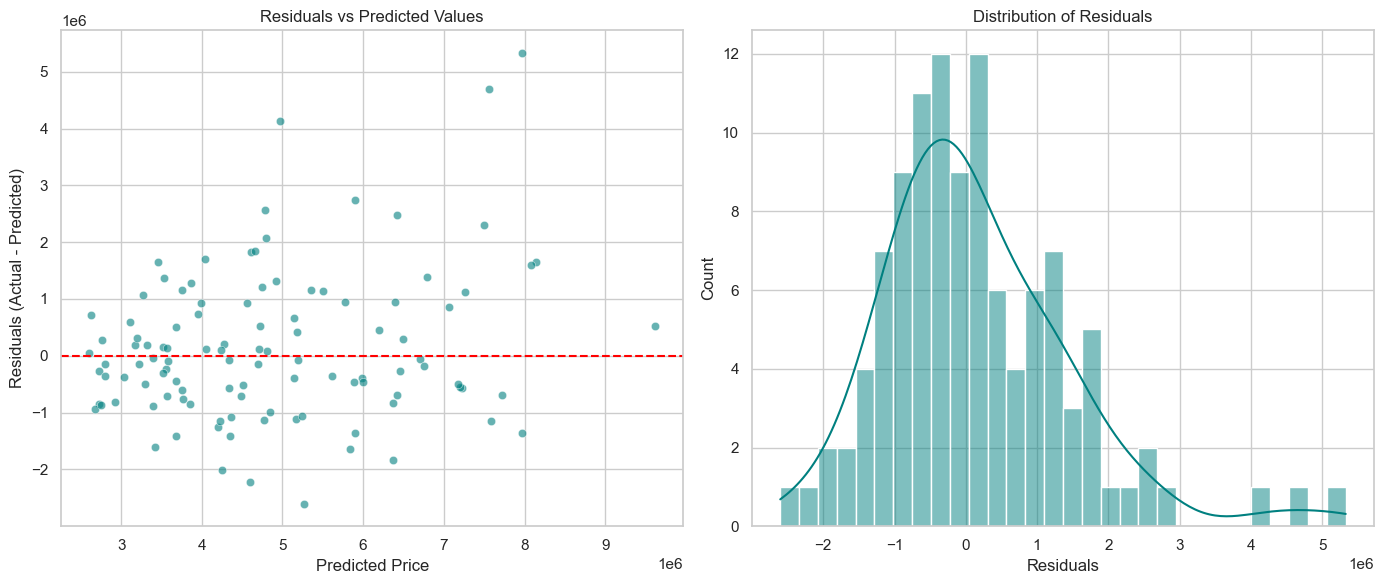

In [16]:
# Calculate residuals
residuals = y_test - y_pred_multiple

plt.figure(figsize=(14, 6))

# Plot 1: Residuals vs Predicted Values
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_multiple, y=residuals, alpha=0.6, color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')

# Plot 2: Distribution of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30, color='teal')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')

plt.tight_layout()
plt.show()

### Cell 8: Apply Feature Scaling and Regularization (Ridge & Lasso).
When features are on different scales, or if multicollinearity exists, standard Linear Regression can overfit. 
- **StandardScaler** ensures all features have a mean of 0 and variance of 1.
- **Ridge (L2)** and **Lasso (L1)** regression add a penalty to the loss function to shrink coefficients and prevent overfitting. Lasso can also perform feature selection by shrinking some coefficients to exactly zero.

In [17]:
# 1. Scale the features (Fit on train, transform on both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train Regularized Models
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)

# 3. Evaluate and Compare
print("--- Regularized Models Evaluation (R² Score) ---")
print(f"Multiple Linear Regression: {r2_score(y_test, model_multiple.predict(X_test)):.4f}")
print(f"Ridge Regression (L2):      {r2_score(y_test, ridge_model.predict(X_test_scaled)):.4f}")
print(f"Lasso Regression (L1):      {r2_score(y_test, lasso_model.predict(X_test_scaled)):.4f}")

--- Regularized Models Evaluation (R² Score) ---
Multiple Linear Regression: 0.6529
Ridge Regression (L2):      0.6528
Lasso Regression (L1):      0.6529


### Cell 9: Perform K-Fold Cross-Validation for robust performance estimation.
A single train-test split can be biased depending on how the data is shuffled. K-Fold Cross-Validation (e.g., 5 folds) trains and evaluates the model on different subsets of the data, providing a more reliable and robust estimate of the model's true performance (mean R² and standard deviation).

In [18]:
# Perform 5-Fold Cross-Validation on the Multiple Linear Regression model
cv_scores = cross_val_score(model_multiple, X, y, cv=5, scoring='r2')

print("--- 5-Fold Cross-Validation Results (R²) ---")
print(f"Fold Scores: {np.round(cv_scores, 4)}")
print(f"Mean R²:     {np.mean(cv_scores):.4f}")
print(f"Std Dev:     {np.std(cv_scores):.4f}")

--- 5-Fold Cross-Validation Results (R²) ---
Fold Scores: [ -2.0876  -5.1563 -16.3449 -20.807   -5.1641]
Mean R²:     -9.9120
Std Dev:     7.3002


## Summary

1. **Model Performance**: 
   - **Simple Linear Regression** (using only `area`) achieved an R² of **0.2729**, indicating that property area alone explains about 27% of the variance in house prices.
   - **Multiple Linear Regression** significantly improved performance, achieving an R² of **0.6529**. This means the model explains roughly 65% of the variance in house prices, and the Mean Absolute Error (MAE) was reduced to ~970,000.

2. **Regularization (Ridge & Lasso)**: 
   - Both **Ridge (L2)** and **Lasso (L1)** regression models performed very similarly to the standard Multiple Linear Regression (R² ≈ 0.65) with the default `alpha=1.0`. 
   - Lasso did not shrink any coefficients to exactly zero at this alpha level, suggesting that all included features contribute to the prediction to some degree, and severe multicollinearity might not be the primary issue at this specific penalty strength.

3. **Cross-Validation Warning**: 
   - The 5-Fold Cross-Validation revealed highly negative R² scores (Mean R²: **-9.91**, Std Dev: **7.30**). A negative R² in cross-validation is a strong indicator of **overfitting** or high variance. It indicates that the model performs well on the specific random train/test split but fails to generalize to other subsets of the data. This is likely due to the relatively small dataset size (545 rows), the presence of extreme outliers, or the need for more aggressive hyperparameter tuning.

4. **Feature Importance**: 
   - Based on the Multiple Linear Regression coefficients, `area` is the most significant predictor of house price, followed by `bedrooms`, `bathrooms`, and `stories`. 
   - Categorical features like `mainroad`, `guestroom`, and `airconditioning` also show positive contributions, meaning their presence adds value to the property.

5. **Residual Analysis**: 
   - The residual plots indicate that while the model captures the general trend, there is still unexplained variance. The residuals show signs of **heteroscedasticity** (the spread of residuals increases as the predicted price increases) and a slight right skew. This suggests that the relationship between features and price might not be strictly linear.